
# Tugas A
## Klasifikasi Dataset Iris dan Wine

**Nama:** ARSYA APRILIANI

**NIM:** 2553190001

**Mata Kuliah:** Pembelajaran mesin dan kecerdasan buatan

Notebook ini mereplikasi alur klasifikasi menggunakan dataset Iris, kemudian menerapkan alur yang sama pada dataset Wine.

Tahapan yang dilakukan:
1. Memuat dataset
2. Eksplorasi data
3. Membuat minimal 5 visualisasi
4. Membagi data menjadi data latih dan data uji
5. Melatih model klasifikasi
6. Mengevaluasi model menggunakan classification report
7. Menuliskan Task, Experience, dan Performance

In [41]:

# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

Bagian 1 - Dataset Iris

In [42]:

# Memuat dataset Iris
iris = load_iris()

df_iris = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df_iris["target"] = iris.target
df_iris["target_name"] = df_iris["target"].map(
    dict(enumerate(iris.target_names))
)

df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [43]:

# Informasi umum dataset Iris
print("Jumlah baris dan kolom:", df_iris.shape)
print("\nInformasi dataset:")
df_iris.info()

print("\nStatistik deskriptif:")
display(df_iris.describe())

Jumlah baris dan kolom: (150, 6)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistik deskriptif:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


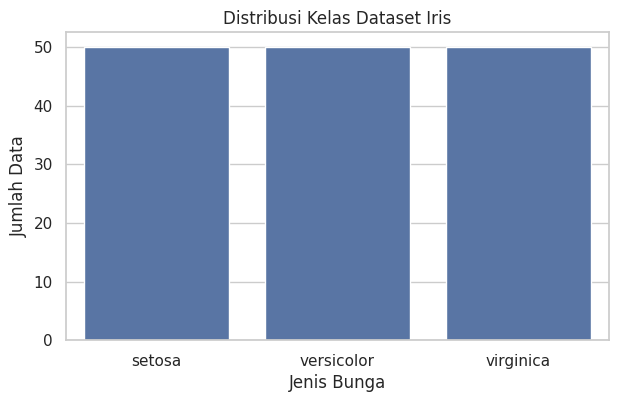

In [44]:

# Distribusi kelas Iris
plt.figure(figsize=(7, 4))
sns.countplot(data=df_iris, x="target_name")
plt.title("Distribusi Kelas Dataset Iris")
plt.xlabel("Jenis Bunga")
plt.ylabel("Jumlah Data")
plt.show()

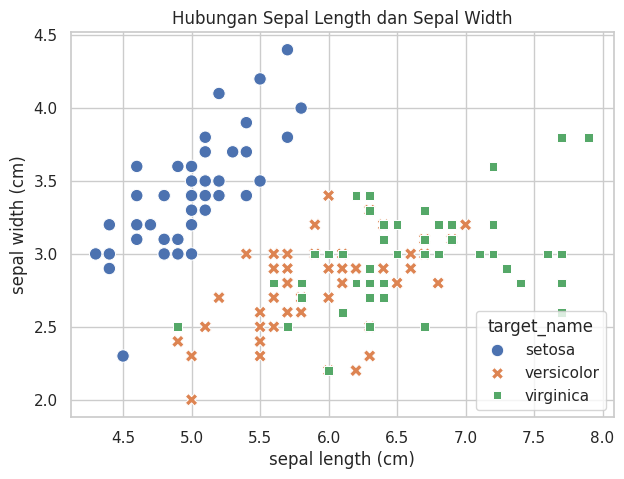

In [45]:

# Visualisasi 2: hubungan panjang dan lebar sepal
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_iris,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="target_name",
    style="target_name",
    s=80
)
plt.title("Hubungan Sepal Length dan Sepal Width")
plt.show()

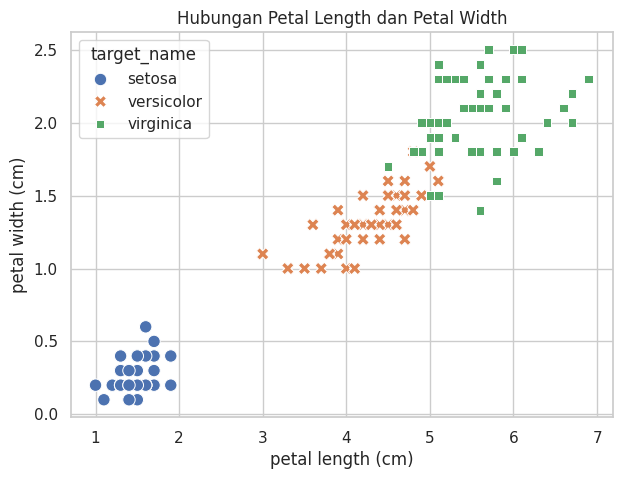

In [46]:

# Visualisasi 3: hubungan panjang dan lebar petal
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_iris,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="target_name",
    style="target_name",
    s=80
)
plt.title("Hubungan Petal Length dan Petal Width")
plt.show()

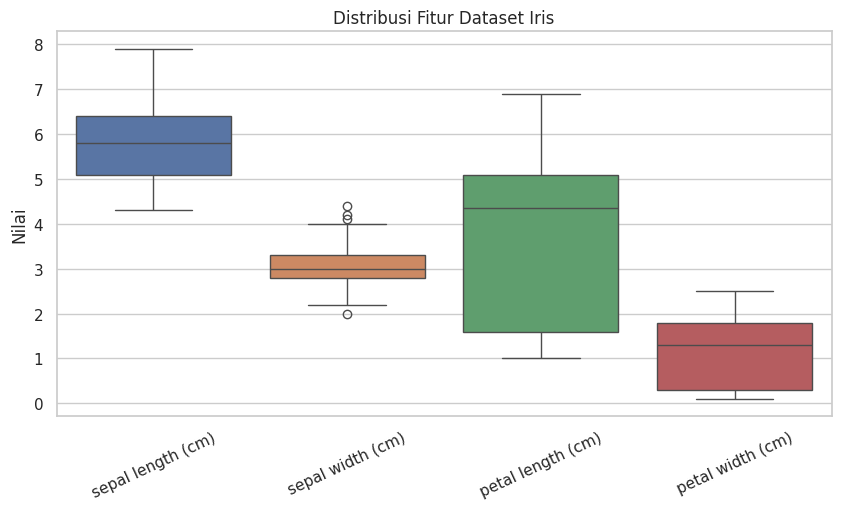

In [47]:

# Visualisasi 4: boxplot seluruh fitur
iris_features = iris.feature_names

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_iris[iris_features])
plt.title("Distribusi Fitur Dataset Iris")
plt.xticks(rotation=25)
plt.ylabel("Nilai")
plt.show()

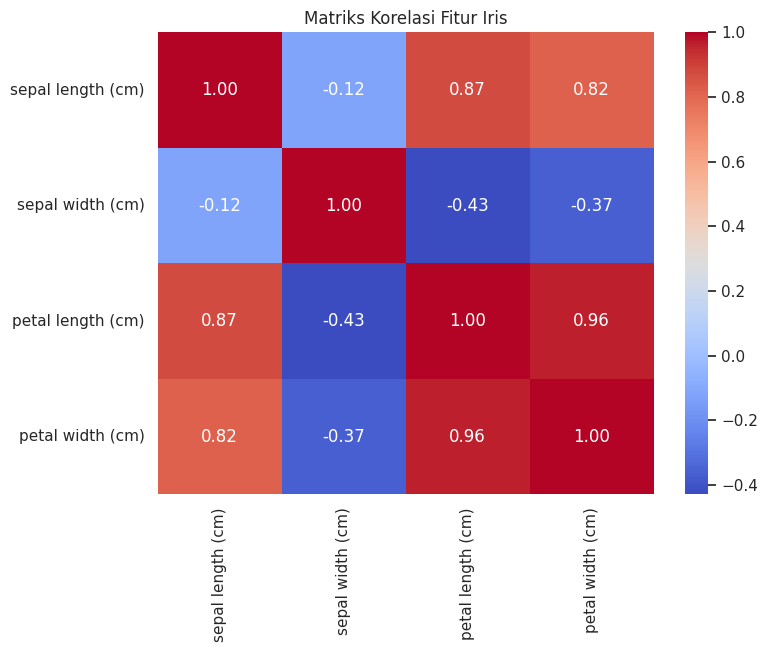

In [48]:

# Visualisasi 5: korelasi antarfitur
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_iris[iris_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriks Korelasi Fitur Iris")
plt.show()

Pelatihan Model Iris

In [49]:

X_iris = df_iris[iris_features]
y_iris = df_iris["target"]

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

model_iris = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

model_iris.fit(X_train_iris, y_train_iris)
y_pred_iris = model_iris.predict(X_test_iris)

print("Akurasi Iris:", accuracy_score(y_test_iris, y_pred_iris))
print("\nClassification Report Iris:")
print(classification_report(
    y_test_iris,
    y_pred_iris,
    target_names=iris.target_names
))

Akurasi Iris: 0.9333333333333333

Classification Report Iris:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



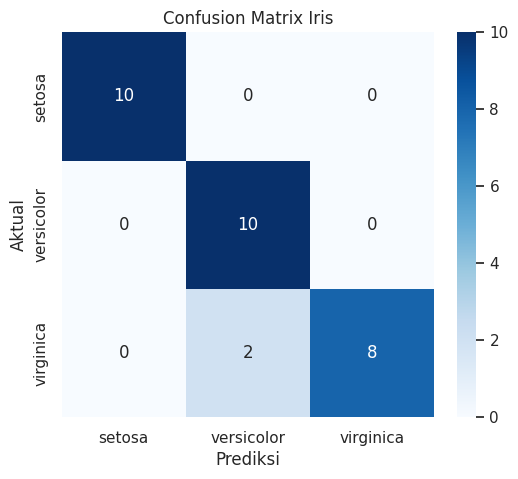

In [50]:

# Confusion matrix Iris
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_iris,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Confusion Matrix Iris")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()


### Task, Experience, dan Performance — Iris

**Task:**  
Membangun model klasifikasi untuk memprediksi jenis bunga Iris berdasarkan empat fitur, yaitu panjang sepal, lebar sepal, panjang petal, dan lebar petal.

**Experience:**  
Dataset Iris memiliki tiga kelas bunga. Tahap eksplorasi menunjukkan bahwa fitur petal cenderung lebih mudah membedakan kelas dibandingkan fitur sepal. Data kemudian dibagi menjadi data latih dan data uji, lalu fitur distandardisasi sebelum digunakan oleh algoritma K-Nearest Neighbors.

**Performance:**  
Kinerja model dinilai menggunakan akurasi, precision, recall, f1-score, dan confusion matrix. Nilai tersebut menunjukkan seberapa baik model membedakan tiga jenis bunga pada data uji.

Bagian 2 - Dataset Wine

In [51]:

# Memuat dataset Wine
wine = load_wine()

df_wine = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)
df_wine["target"] = wine.target
df_wine["target_name"] = df_wine["target"].map(
    dict(enumerate(wine.target_names))
)

df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [52]:

print("Jumlah baris dan kolom:", df_wine.shape)
print("\nStatistik deskriptif:")
display(df_wine.describe())

Jumlah baris dan kolom: (178, 15)

Statistik deskriptif:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


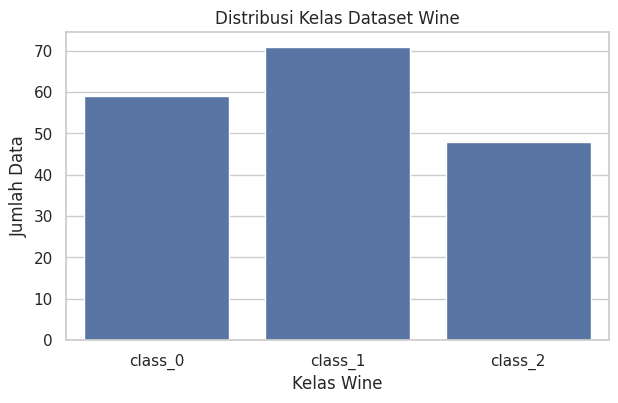

In [53]:

# Visualisasi Wine 1: distribusi kelas
plt.figure(figsize=(7, 4))
sns.countplot(data=df_wine, x="target_name")
plt.title("Distribusi Kelas Dataset Wine")
plt.xlabel("Kelas Wine")
plt.ylabel("Jumlah Data")
plt.show()

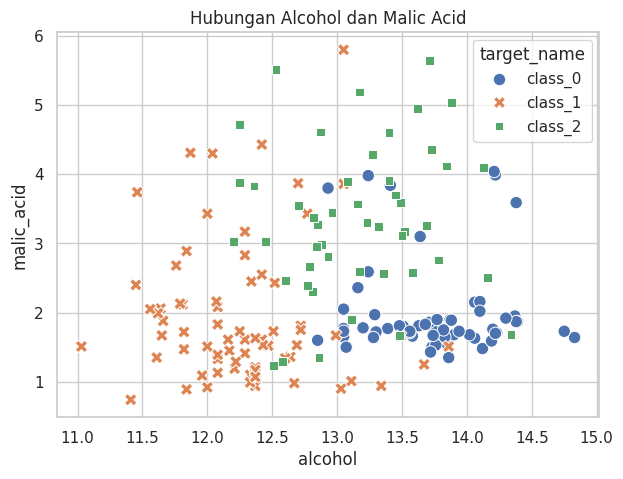

In [54]:

# Visualisasi Wine 2: hubungan alcohol dan malic_acid
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_wine,
    x="alcohol",
    y="malic_acid",
    hue="target_name",
    style="target_name",
    s=80
)
plt.title("Hubungan Alcohol dan Malic Acid")
plt.show()

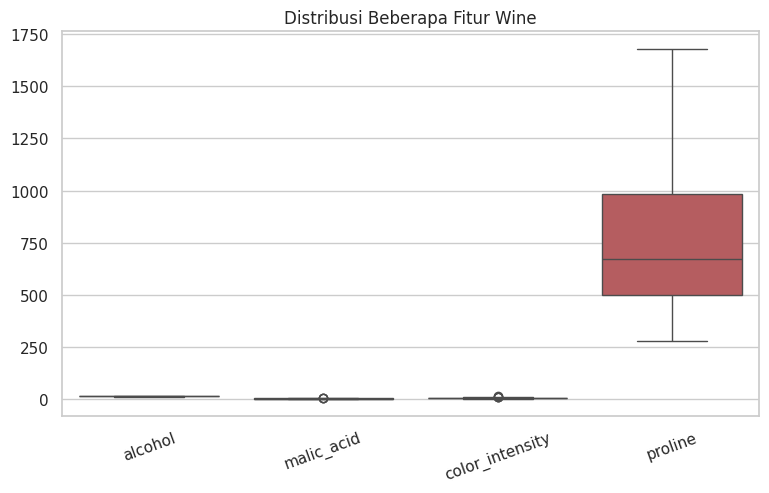

In [55]:

# Visualisasi Wine 3: boxplot beberapa fitur
selected_wine_features = ["alcohol", "malic_acid", "color_intensity", "proline"]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_wine[selected_wine_features])
plt.title("Distribusi Beberapa Fitur Wine")
plt.xticks(rotation=20)
plt.show()

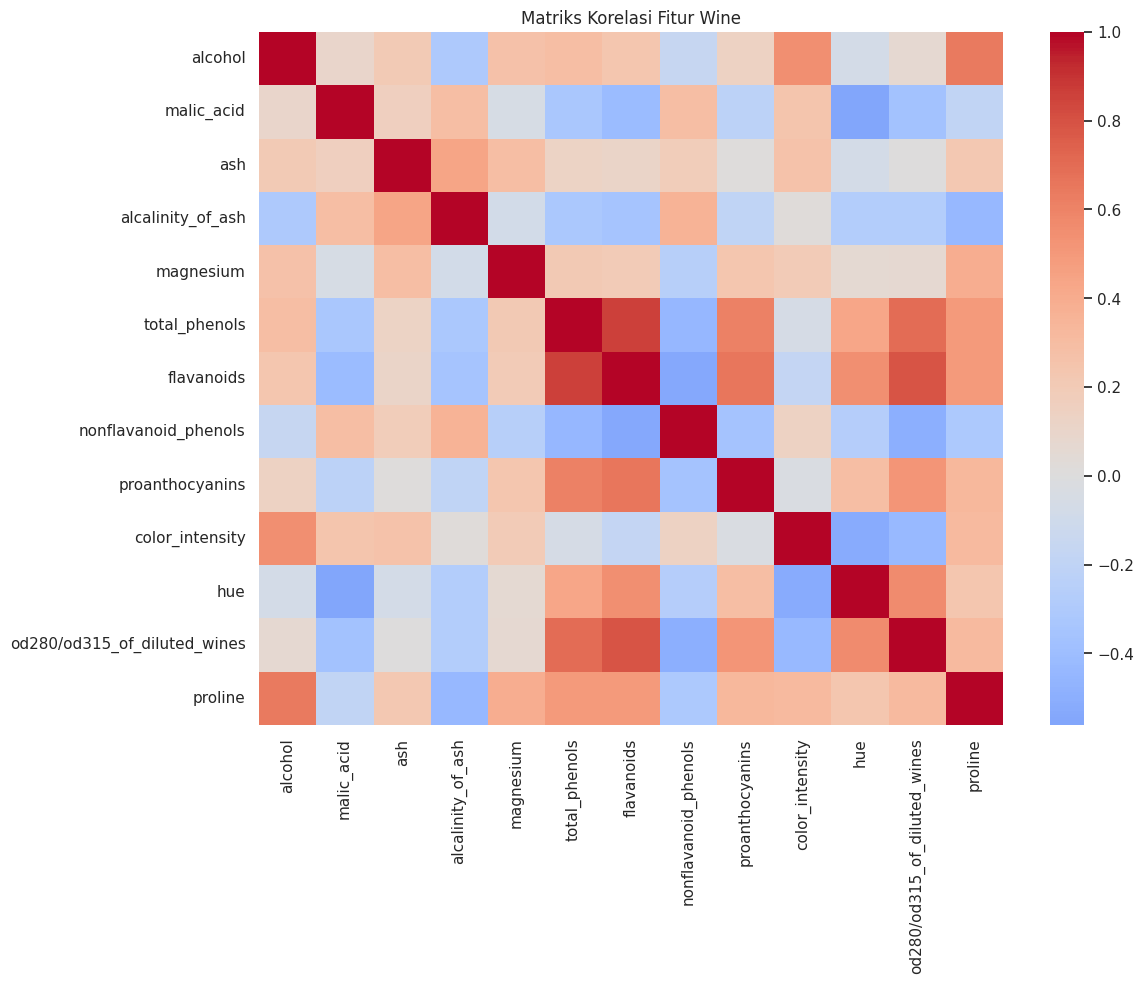

In [56]:

# Visualisasi Wine 4: korelasi fitur
plt.figure(figsize=(12, 9))
sns.heatmap(
    df_wine[wine.feature_names].corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Matriks Korelasi Fitur Wine")
plt.show()

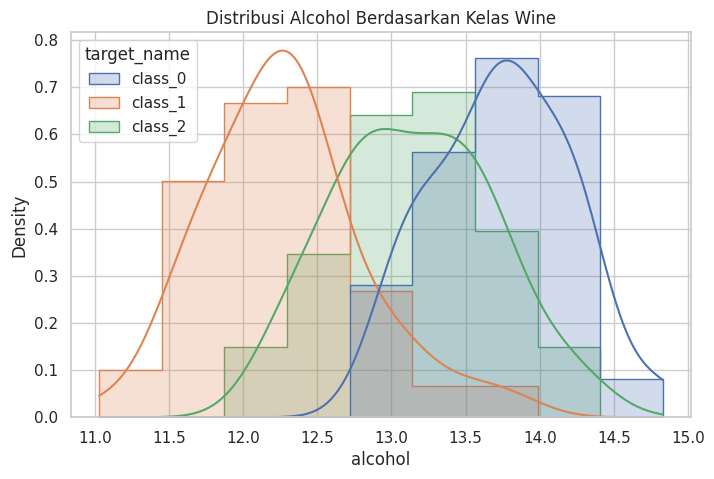

In [57]:

# Visualisasi Wine 5: distribusi alcohol berdasarkan kelas
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_wine,
    x="alcohol",
    hue="target_name",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Distribusi Alcohol Berdasarkan Kelas Wine")
plt.show()

Pelatihan Model Wine

In [58]:

X_wine = df_wine[wine.feature_names]
y_wine = df_wine["target"]

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine
)

model_wine = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

model_wine.fit(X_train_wine, y_train_wine)
y_pred_wine = model_wine.predict(X_test_wine)

print("Akurasi Wine:", accuracy_score(y_test_wine, y_pred_wine))
print("\nClassification Report Wine:")
print(classification_report(
    y_test_wine,
    y_pred_wine,
    target_names=wine.target_names
))

Akurasi Wine: 0.9722222222222222

Classification Report Wine:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



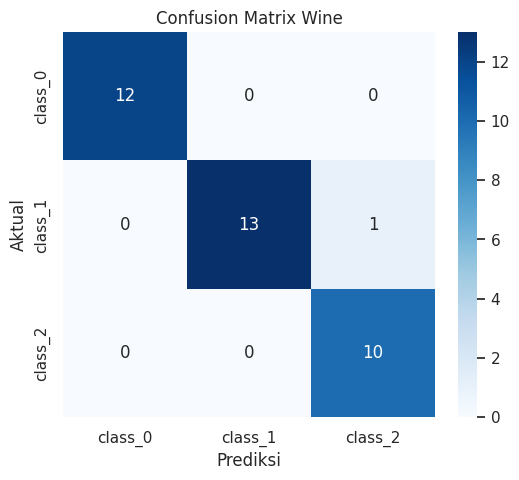

In [59]:

# Confusion matrix Wine
cm_wine = confusion_matrix(y_test_wine, y_pred_wine)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_wine,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)
plt.title("Confusion Matrix Wine")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()


### Task, Experience, dan Performance — Wine

**Task:**  
Menerapkan pipeline klasifikasi pada dataset Wine untuk memprediksi kelas wine berdasarkan karakteristik kimianya.

**Experience:**  
Dataset Wine memiliki beberapa fitur kimia dengan skala yang berbeda. Oleh karena itu, standardisasi diperlukan sebelum menjalankan K-Nearest Neighbors. Eksplorasi visual menunjukkan adanya perbedaan karakteristik antar kelas wine.

**Performance:**  
Model dievaluasi menggunakan akurasi, precision, recall, f1-score, dan confusion matrix. Hasil evaluasi digunakan untuk melihat kemampuan model dalam mengklasifikasikan tiga kelas wine pada data uji.


## Kesimpulan

Pada notebook ini, pipeline klasifikasi berhasil diterapkan pada dataset Iris dan Wine. Kedua dataset melalui tahapan pemuatan data, eksplorasi, visualisasi, pembagian data, standardisasi, pelatihan model, dan evaluasi.

Model K-Nearest Neighbors digunakan karena dapat melakukan klasifikasi berdasarkan kedekatan antar data. Standardisasi fitur membantu membuat skala setiap variabel lebih seimbang. Evaluasi melalui classification report dan confusion matrix memberikan gambaran mengenai ketepatan prediksi model.